# Coding the GPT model

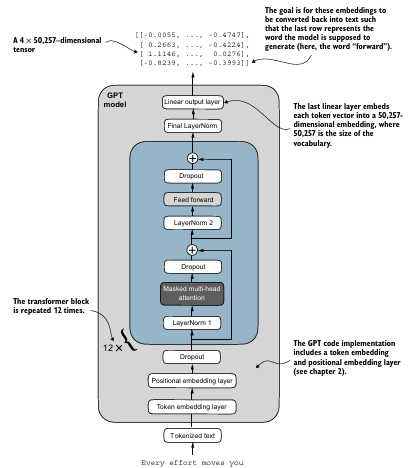

In [1]:
import tiktoken
import torch
import torch.nn as nn

In [2]:
MODEL_CONFIG_124M = {
    "vocab_size": 50257,     
    "context_length": 1024,  
    "emb_dim": 768,          
    "n_heads": 12,           
    "n_layers": 12,          
    "drop_rate": 0.1,        
    "qkv_bias": False   
}

In [3]:
from components import *

In [4]:
class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config["vocab_size"], config["emb_dim"])
        self.pos_emb = nn.Embedding(config["context_length"], config["emb_dim"])
        self.drop_emb = nn.Dropout(config["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(config) for _ in range(config["n_layers"])])
        self.final_norm = LayerNorm(config["emb_dim"])
        self.out_head = nn.Linear(
            config["emb_dim"], config["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
          torch.arange(seq_len, device=in_idx.device)
        )
        input = tok_embeds + pos_embeds
        input = self.drop_emb(input)
        input = self.trf_blocks(input)
        input = self.final_norm(input)
        logits = self.out_head(input)
        return logits

In [5]:
tokenizer = tiktoken.get_encoding("gpt2")

batch = []
raw_text1 = "Every effort moves you"
raw_text2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(raw_text1)))
batch.append(torch.tensor(tokenizer.encode(raw_text2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [6]:
torch.manual_seed(123)

model = GPTModel(MODEL_CONFIG_124M)
output = model(batch)

In [7]:
output.shape

torch.Size([2, 4, 50257])

## Model size analysis

In [8]:
total_params = sum(params.numel() for params in model.parameters())
print(f"{total_params:,}")

163,009,536


In [9]:
print(f"{total_params - model.out_head.weight.numel():,}")

124,412,160


## Memory requirenments of model

In [10]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"{total_size_mb:.2f} MB")

621.83 MB


## Generating text from GPT model (untrained)

In [ ]:
def generate_text(model, idx, max_new_tokens, context_size): 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:] 
        """  
        In Pytorch, by default, it is always building this computation graph 
        of the model in the background that is used for the backpropagation algorithm, 
        And if we don't train the model, this very inefficent
        """
        # suppressing the generation of the gradient computation, the computation graph
        with torch.no_grad():  
            logits = model(idx_cond)
            
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)          
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)   
        idx = torch.cat((idx, idx_next), dim=1)
        
    return idx

In [20]:
context = "Hello, I am"

token_ids = tokenizer.encode(context)
print(token_ids)

[15496, 11, 314, 716]


In [21]:
token_ids_tensor = torch.tensor(token_ids).unsqueeze(0) # add batch dimension 
token_ids_tensor.shape

torch.Size([1, 4])

In [24]:
model.eval()

output = generate_text(
    model = model,
    idx = token_ids_tensor,
    max_new_tokens = 6,
    context_size = MODEL_CONFIG_124M["context_length"])

In [25]:
output

tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])

In [28]:
# as decoder() works with python list
tokenizer.decode((output.squeeze(0)).tolist())

'Hello, I am Featureiman Byeswickattribute argue'

The output is more like gebberish 

The reason is we have initialized our model with random weights, and we have not trained yet